In [ ]:
import pandas as pd
import torch 
from torch import nn
from torchvision import transforms
from IPython.display import display
from torch.utils.data import Dataset,DataLoader


batch_size = 64
num_epochs = 10

## 导入数据集

这里使用的是 colab 

In [2]:
# 对于 colab 上运行，注意要先将文件传到 google drive 上

from pathlib import Path
import zipfile
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    # 压缩包永久保存在 Google Drive
    ZIP_PATH = Path(
        "/content/drive/MyDrive/"
        "kaggle-leaves-classification/classify-leaves.zip"
    )

    # 解压到 Colab 临时磁盘，读取图片更快
    DATA_DIR = Path("/content/classify-leaves")

else:
    # 本地运行时，压缩包就在 Notebook 同级目录
    PROJECT_DIR = Path.cwd()
    ZIP_PATH = PROJECT_DIR / "classify-leaves.zip"
    DATA_DIR = PROJECT_DIR / "data"

print("压缩包路径：", ZIP_PATH)
print("数据集目录：", DATA_DIR)

压缩包路径： /Users/tuttokey/Documents/deep-learning-pytorch/chapter_05_convolutional_modern/kaggle-leaves-classification/classify-leaves.zip
数据集目录： /Users/tuttokey/Documents/deep-learning-pytorch/chapter_05_convolutional_modern/kaggle-leaves-classification/data


In [3]:
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"找不到压缩包：{ZIP_PATH}")

train_csv_path = DATA_DIR / "train.csv"

# 防止重复解压
if not train_csv_path.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
        zip_file.extractall(DATA_DIR)

    print("数据集解压完成")
else:
    print("数据集已经存在，不需要重复解压")

数据集已经存在，不需要重复解压


In [4]:
train_data = pd.read_csv(DATA_DIR/'train.csv')
test_data = pd.read_csv(DATA_DIR/'test.csv')

print("训练集：", train_data.shape)
print("测试集：", test_data.shape)

display(train_data.head(3))
display(test_data.head(3))

训练集： (18353, 2)
测试集： (8800, 1)


,image,label
0,images/0.jpg,maclura_pomifera
1,images/1.jpg,maclura_pomifera
2,images/2.jpg,maclura_pomifera


,image
0,images/18353.jpg
1,images/18354.jpg
2,images/18355.jpg


读取一张照片检查

In [5]:
from genericpath import exists


first_image_path = DATA_DIR/train_data.loc[0,"image"]

print(first_image_path)
print("第一张照片是否存在:",first_image_path.exists())

/Users/tuttokey/Documents/deep-learning-pytorch/chapter_05_convolutional_modern/kaggle-leaves-classification/data/images/0.jpg
第一张照片是否存在: True


<function matplotlib.pyplot.show(close=None, block=None)>

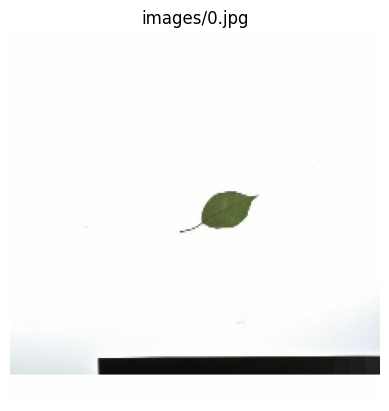

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(first_image_path).convert("RGB")

plt.imshow(image)
plt.title(train_data.loc[0,"image"])
plt.axis("off")
plt.show

显示正常，可以读取数据集了

先将一个照片转为tensor，查看其shape

In [7]:
transform = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ]
)

image_tensor = transform(image)
print(type(image_tensor))
print(image_tensor.shape)
print(image_tensor.dtype)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
torch.float32


对于整个数据集，两万张照片一次性读入内存虽然可以，但数据集一大，内存可能会爆，所以我们定义一个 Dataset，训练到哪张就读取哪张。

In [8]:
class LeavesDataset(Dataset):

    def __init__(self, data, data_dir, transform, label_to_index=None):
        self.data = data.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform
        self.label_to_index = label_to_index
        self.has_label = "label" in self.data.columns

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # images/0.jpg 是相对路径，需要和 DATA_DIR 拼接
        image_path = self.data_dir / row["image"]

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        if self.has_label:
            label = self.label_to_index[row["label"]]
            label = torch.tensor(label, dtype=torch.long)

            return image, label

        return image

将文字label 转为数字 label

In [9]:
labels = sorted(train_data["label"].unique())

# 文字标签 → 数字
label_to_index = {label: index for index, label in enumerate(labels)}

# 数字 → 文字标签
index_to_label = {index: label for index, label in enumerate(labels)}

num_classes = len(labels)

print("类别数量：", num_classes)
print("第一个类别：", labels[0])
print("转换成数字：", label_to_index[labels[0]])
print("数字转回类别：", index_to_label[0])

类别数量： 176
第一个类别： abies_concolor
转换成数字： 0
数字转回类别： abies_concolor


## 划分验证集和数据集

In [10]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_data, test_size=0.2, random_state=42, stratify=train_data["label"]
)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

In [11]:
train_dataset = LeavesDataset(
    data=train_split,
    data_dir=DATA_DIR,
    transform=transform,
    label_to_index=label_to_index,
)

val_dataset = LeavesDataset(
    data=val_split,
    data_dir=DATA_DIR,
    transform=transform,
    label_to_index=label_to_index,
)

test_dataset = LeavesDataset(data=test_data, data_dir=DATA_DIR, transform=transform)


In [12]:
train_image, train_label = train_dataset[0]
val_image, val_label = val_dataset[0]
test_image = test_dataset[0]

print("训练集数量：", len(train_dataset))
print("验证集数量：", len(val_dataset))
print("测试集数量：", len(test_dataset))

print("训练图片形状：", train_image.shape)
print("训练标签：", train_label)
print("标签的数据类型：", train_label.dtype)
print("标签对应的类别：", index_to_label[train_label.item()])

print("验证图片形状：", val_image.shape)
print("测试图片形状：", test_image.shape)


训练集数量： 14682
验证集数量： 3671
测试集数量： 8800
训练图片形状： torch.Size([3, 224, 224])
训练标签： tensor(43)
标签的数据类型： torch.int64
标签对应的类别： cercidiphyllum_japonicum
验证图片形状： torch.Size([3, 224, 224])
测试图片形状： torch.Size([3, 224, 224])


In [13]:
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
)

val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=0
)

test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0
)


In [14]:
images,labels = next(iter(train_loader))

print("一批图片的形状：", images.shape)
print("一批标签的形状：", labels.shape)
print("图片数据类型：", images.dtype)
print("标签数据类型：", labels.dtype)

一批图片的形状： torch.Size([64, 3, 224, 224])
一批标签的形状： torch.Size([64])
图片数据类型： torch.float32
标签数据类型： torch.int64


## 训练模型

In [15]:
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
transform = weights.transforms()

image_tensor = transform(image)

print(image_tensor.shape)
print(image_tensor.dtype)


torch.Size([3, 224, 224])
torch.float32


In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("训练设备为:",device)

训练设备为: mps


In [17]:
from torchvision.models import resnet18
model = resnet18(weights=weights)

# 把原来的1000分类改成176分类
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print("训练设备：", device)
print("模型输出层：", model.fc)


训练设备： mps
模型输出层： Linear(in_features=512, out_features=176, bias=True)


In [18]:
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 清除上一批数据产生的梯度
        optimizer.zero_grad()

        # 前向传播
        outputs = model(images)

        # 计算损失
        loss = loss_fn(outputs, labels)

        # 反向传播
        loss.backward()

        # 更新模型参数
        optimizer.step()

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


In [19]:
def evaluate_model(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # 验证时不计算梯度
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            batch_size = images.size(0)

            total_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


In [20]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

best_val_accuracy = -1.0
best_model_path = ZIP_PATH.parent / "best_resnet18.pth"

for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, loss_fn, optimizer, device
    )

    val_loss, val_accuracy = evaluate_model(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"训练损失：{train_loss:.4f} | "
        f"训练准确率：{train_accuracy:.2%} | "
        f"验证损失：{val_loss:.4f} | "
        f"验证准确率：{val_accuracy:.2%}"
    )

    # 保存验证准确率最高的模型
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), best_model_path)
        print("保存当前最佳模型")

print("最佳验证准确率：", f"{best_val_accuracy:.2%}")
print("模型保存位置：", best_model_path)


KeyboardInterrupt: 